# AIRPATH-AI Milestone 4 — route exposure aggregation validation

This notebook evaluates the offline route index

`E(route) = Σ segment_PM2.5 × segment_duration_minutes`.

The index is a time-weighted PM2.5 exposure proxy in `(µg/m³)·min`, not inhaled dose. Oracle and predicted pathways remain separate. Candidate ranks are evaluation labels only: this notebook does not optimize, recommend, or constrain routes, and it does not validate minute-level PM2.5.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.exposure import generate_exposure_outputs

In [2]:
output_directory = PROJECT_ROOT / "data/processed/exposure"
outputs = generate_exposure_outputs(
    prediction_csv=PROJECT_ROOT / "data/processed/xgboost_forecasting_predictions.csv",
    network_path=PROJECT_ROOT / "data/processed/road_network/healthyair_pilot_osm.json.gz",
    output_directory=output_directory,
    report_path=PROJECT_ROOT / "reports/route_exposure.md",
)
outputs["route_summary"]

,scenario_id,mode,route_id,total_distance_m,total_travel_time_minutes,segment_count,oracle_exposure_index,predicted_exposure_index,exposure_difference,absolute_exposure_error,percentage_difference,absolute_percentage_error,mean_nearest_station_distance_km,max_nearest_station_distance_km,mean_effective_station_count,moderate_or_weak_segment_fraction
0,s6_to_s5,walking,walking-1,3882.403577,46.588843,121,1283.482137,1090.550231,-192.931906,192.931906,-15.031912,15.031912,0.955480,1.603024,2.807516,0.066116
1,s6_to_s5,walking,walking-2,3882.719899,46.592639,120,1283.572006,1090.633077,-192.938929,192.938929,-15.031407,15.031407,0.954099,1.603024,2.804390,0.066667
2,s6_to_s5,walking,walking-3,3883.703751,46.604445,120,1283.911446,1090.914321,-192.997125,192.997125,-15.031965,15.031965,0.952862,1.603024,2.802694,0.066667
3,s6_to_s5,walking,walking-4,3884.020073,46.608241,119,1284.001315,1090.997167,-193.004148,193.004148,-15.031460,15.031460,0.951448,1.603024,2.799501,0.067227
4,s6_to_s5,walking,walking-5,3884.209832,46.610518,121,1286.748787,1092.480535,-194.268252,194.268252,-15.097605,15.097605,0.957143,1.603024,2.810534,0.066116
5,s6_to_s5,motorbike,motorbike-1,3869.319300,9.286366,133,254.413401,216.597734,-37.815667,37.815667,-14.863866,14.863866,0.899438,1.603024,2.702117,0.022556
6,s6_to_s5,motorbike,motorbike-2,3872.513760,9.294033,130,254.664260,216.801212,-37.863048,37.863048,-14.867829,14.867829,0.914758,1.603024,2.732124,0.023077
7,s6_to_s5,motorbike,motorbike-3,3877.145954,9.305150,129,255.009010,217.074259,-37.934751,37.934751,-14.875847,14.875847,0.900758,1.603024,2.701224,0.023256
8,s6_to_s5,motorbike,motorbike-4,3880.340413,9.312817,126,255.259869,217.277738,-37.982132,37.982132,-14.879790,14.879790,0.916596,1.603024,2.732163,0.023810
9,s6_to_s5,motorbike,motorbike-5,3883.703751,9.320889,120,256.782289,218.182864,-38.599425,38.599425,-15.031965,15.031965,0.952862,1.603024,2.802694,0.066667


In [3]:
display(outputs["error_metrics"])
display(outputs["agreement"])
display(outputs["ranking"])

,mode,routes,mae_exposure_index,rmse_exposure_index,mean_absolute_percentage_error,max_absolute_percentage_error
0,motorbike,10,133.403255,163.984176,24.259462,33.618310
1,walking,10,564.887334,676.186697,22.802979,30.562308


,scenario_id,mode,route_count,spearman_rank_correlation,kendall_tau_a,oracle_top_1_route,predicted_top_1_route,top_1_agreement,top_2_overlap_count,top_2_overlap_fraction
0,s2_to_s6,motorbike,5,0.6,0.4,motorbike-1,motorbike-1,True,1,0.5
1,s2_to_s6,walking,5,0.9,0.8,walking-1,walking-1,True,2,1.0
2,s6_to_s5,motorbike,5,1.0,1.0,motorbike-1,motorbike-1,True,2,1.0
3,s6_to_s5,walking,5,1.0,1.0,walking-1,walking-1,True,2,1.0


,scenario_id,mode,route_id,oracle_exposure_index,predicted_exposure_index,oracle_rank,predicted_rank,rank_shift
0,s2_to_s6,motorbike,motorbike-1,680.447676,451.721398,1,1,0
1,s2_to_s6,motorbike,motorbike-2,680.583085,451.789314,4,2,-2
2,s2_to_s6,motorbike,motorbike-3,680.539982,451.800689,2,4,2
3,s2_to_s6,motorbike,motorbike-4,680.567834,451.800644,3,3,0
4,s2_to_s6,motorbike,motorbike-5,680.614193,451.803201,5,5,0
5,s2_to_s6,walking,walking-1,3063.996478,2127.589366,1,1,0
6,s2_to_s6,walking,walking-2,3064.236493,2127.812159,2,2,0
7,s2_to_s6,walking,walking-3,3064.597268,2127.985599,3,3,0
8,s2_to_s6,walking,walking-4,3064.837283,2128.208392,4,5,1
9,s2_to_s6,walking,walking-5,3064.865638,2128.204663,5,4,-1


In [4]:
display(
    outputs["top_segments"][[
        "scenario_id",
        "mode",
        "route_id",
        "pipeline_mode",
        "segment_index",
        "pm25_estimate",
        "segment_duration_minutes",
        "exposure_contribution",
        "contribution_fraction",
    ]].head(20)
)
display(outputs["relationships"])

,scenario_id,mode,route_id,pipeline_mode,segment_index,pm25_estimate,segment_duration_minutes,exposure_contribution,contribution_fraction
0,s2_to_s6,motorbike,motorbike-1,oracle_exposure,24,45.193094,0.289535,13.084964,0.019230
1,s2_to_s6,motorbike,motorbike-1,oracle_exposure,274,33.281750,0.368194,12.254143,0.018009
2,s2_to_s6,motorbike,motorbike-1,oracle_exposure,22,45.818853,0.238545,10.929880,0.016063
3,s2_to_s6,motorbike,motorbike-1,oracle_exposure,269,33.362099,0.312131,10.413359,0.015304
4,s2_to_s6,motorbike,motorbike-1,oracle_exposure,17,46.856144,0.219845,10.301096,0.015139
5,s2_to_s6,motorbike,motorbike-1,predicted_exposure,274,26.632684,0.368194,9.805996,0.021708
6,s2_to_s6,motorbike,motorbike-1,predicted_exposure,269,26.331581,0.312131,8.218913,0.018195
7,s2_to_s6,motorbike,motorbike-1,predicted_exposure,266,26.221405,0.281056,7.369671,0.016315
8,s2_to_s6,motorbike,motorbike-1,predicted_exposure,24,24.708684,0.289535,7.154019,0.015837
9,s2_to_s6,motorbike,motorbike-1,predicted_exposure,263,26.140256,0.243953,6.376982,0.014117


,mode,proxy,routes,spearman_with_absolute_exposure_error
0,motorbike,total_distance_m,10,0.963636
1,motorbike,total_travel_time_minutes,10,0.963636
2,motorbike,mean_nearest_station_distance_km,10,0.818182
3,motorbike,max_nearest_station_distance_km,10,0.870388
4,motorbike,mean_effective_station_count,10,0.793939
5,motorbike,moderate_or_weak_segment_fraction,10,0.832831
6,walking,total_distance_m,10,1.000000
7,walking,total_travel_time_minutes,10,1.000000
8,walking,mean_nearest_station_distance_km,10,0.733333
9,walking,max_nearest_station_distance_km,10,0.870388


In [5]:
outputs["decision"]

ExposureReadinessDecision(classification='B. READY WITH RESTRICTIONS', rationale='Exposure ranking is sufficiently stable for further offline work, but one or more strict agreement/error gates fail.', criteria={'top_1_agreement_rate': 1.0, 'mean_spearman_rank_correlation': 0.8749999999999999, 'minimum_scenario_spearman': 0.6, 'maximum_mode_mape_percent': 24.2594617350267, 'strict_top_1_agreement_all': True, 'strict_mean_spearman_ge_0_9': False, 'strict_minimum_spearman_ge_0_8': False, 'strict_maximum_mode_mape_le_10': False, 'restricted_top_1_agreement_ge_half': True, 'restricted_mean_spearman_ge_0_6': True, 'restricted_no_negative_scenario_spearman': True, 'restricted_maximum_mode_mape_le_25': True})

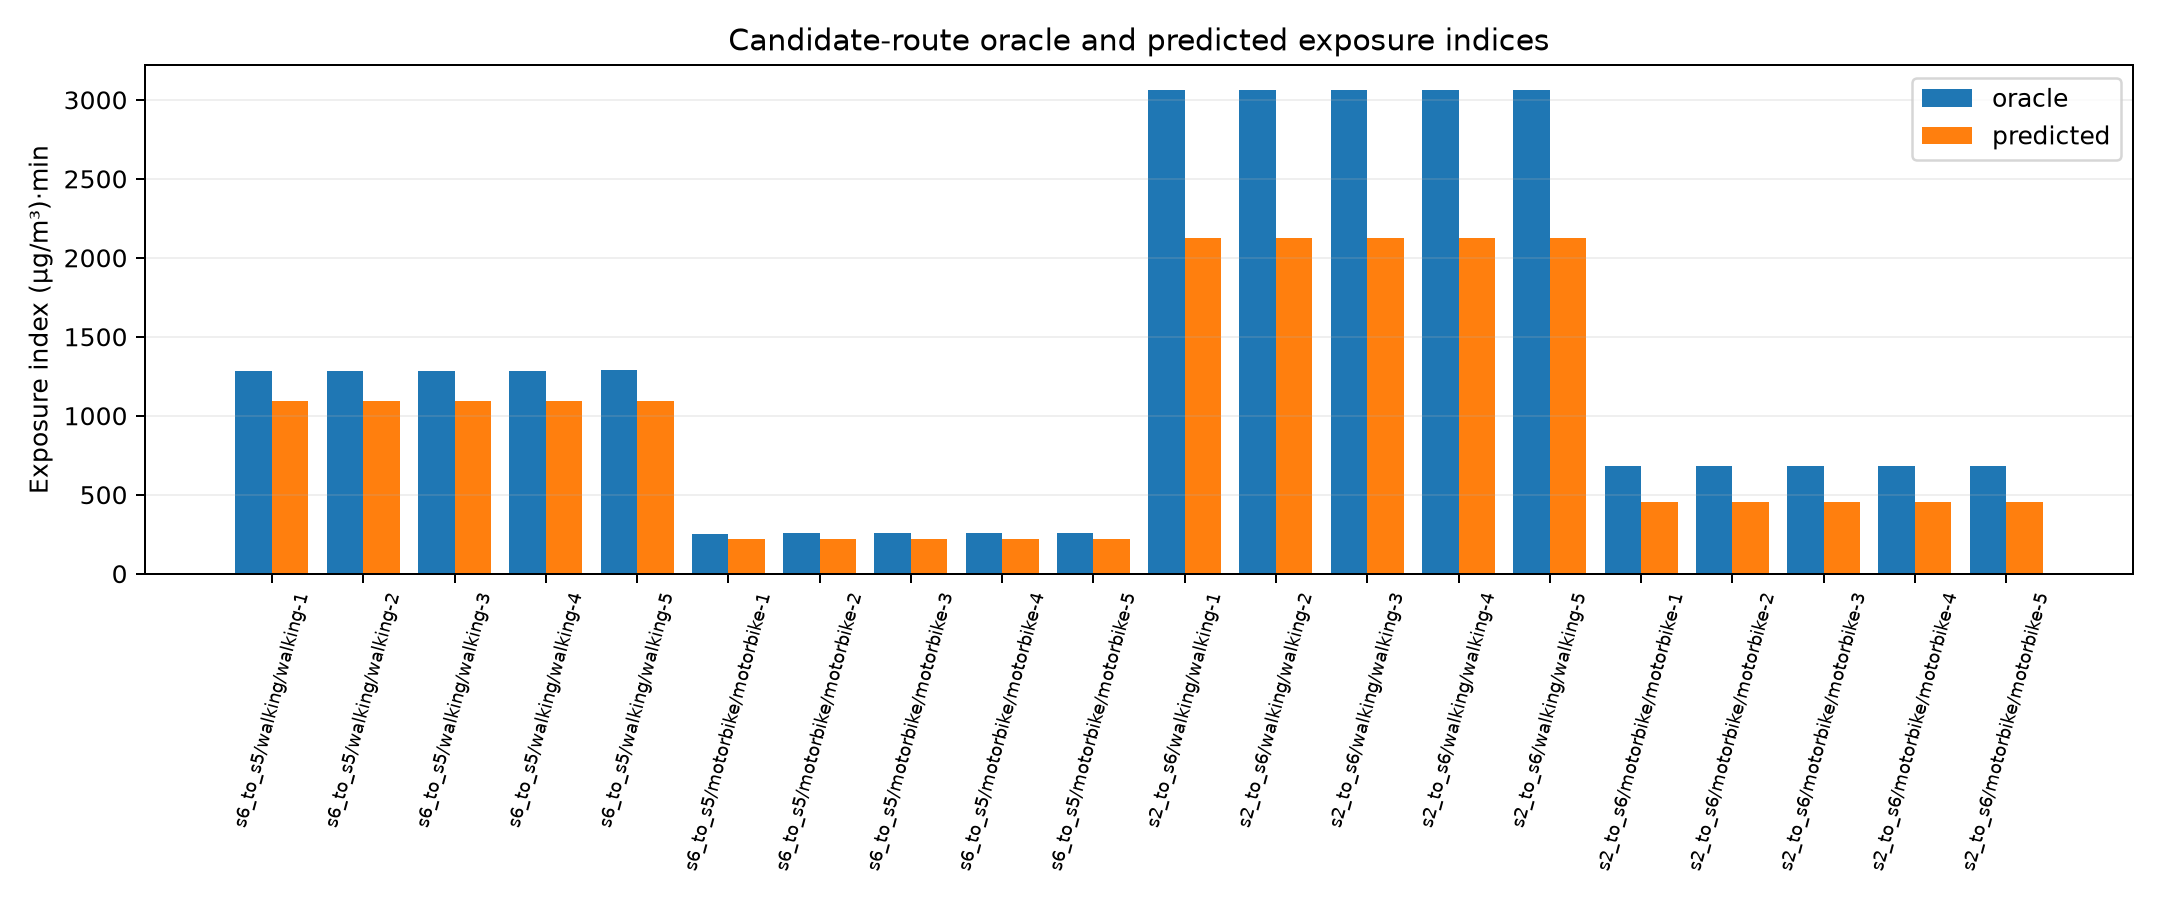

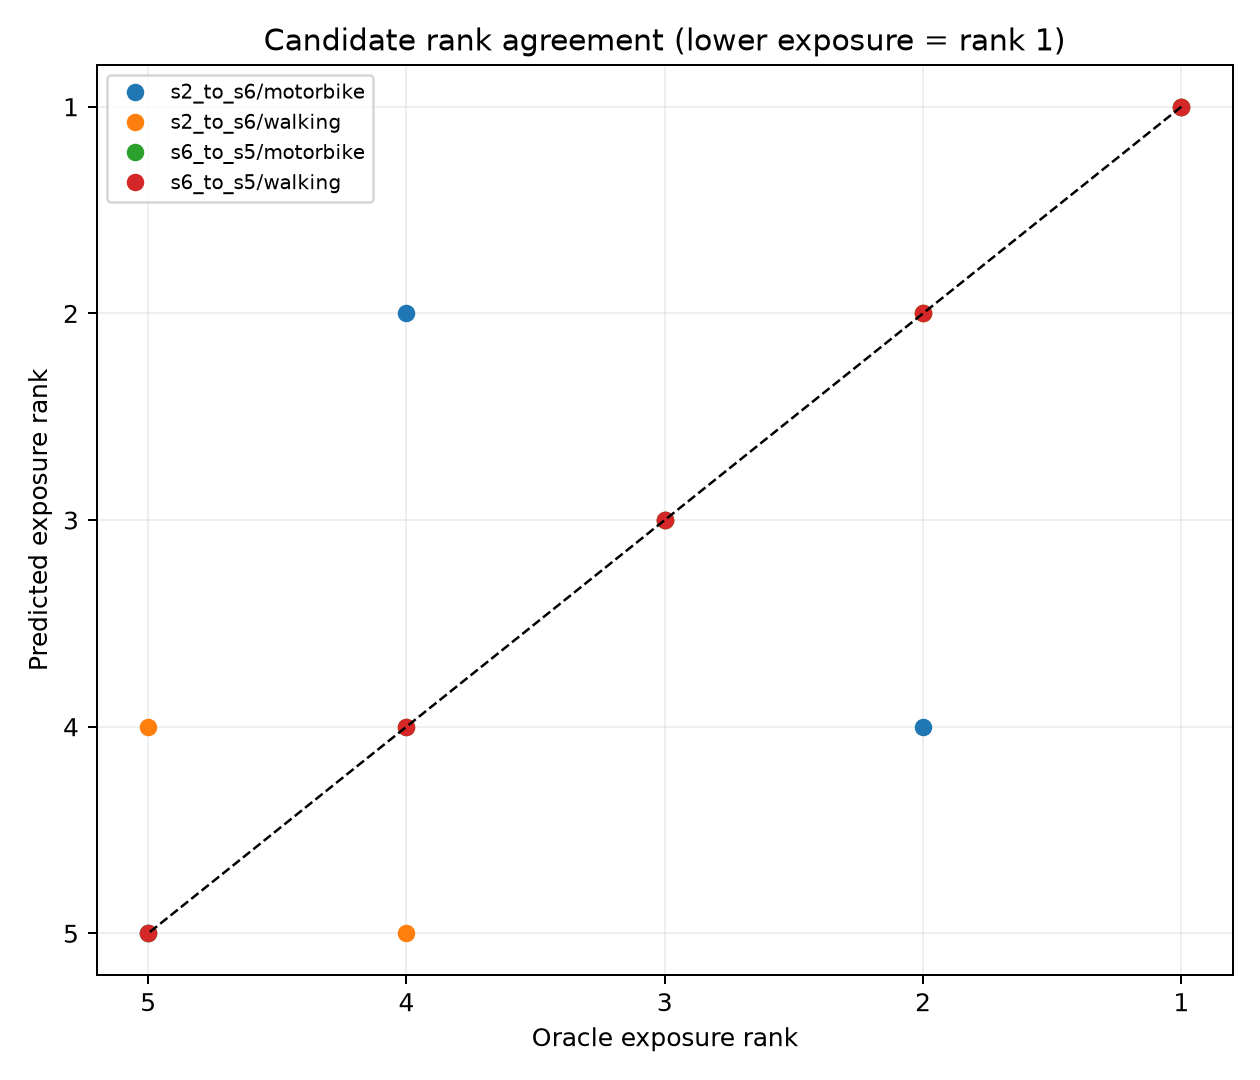

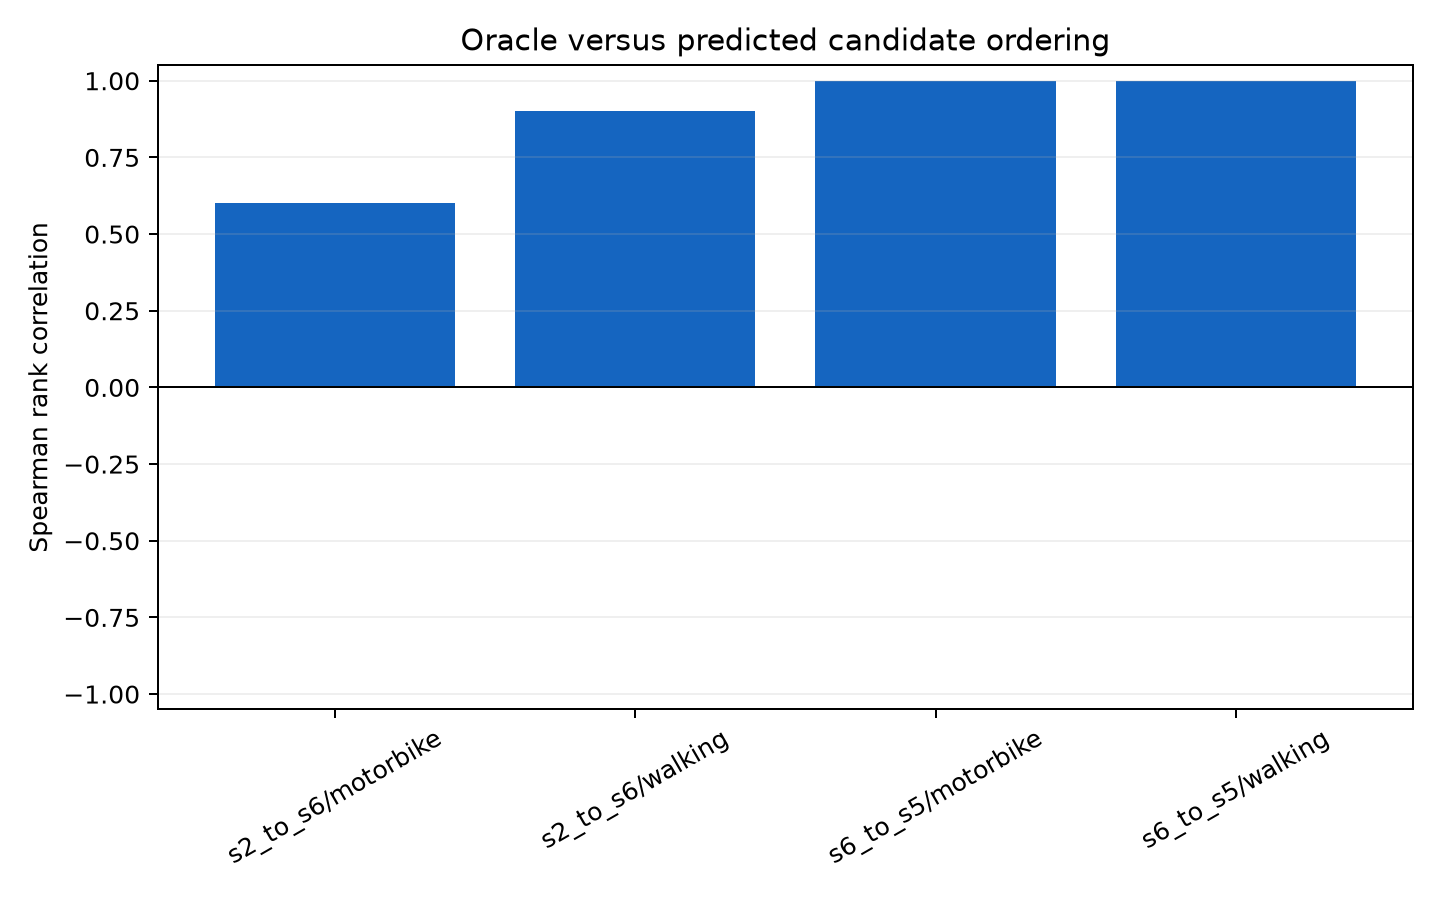

In [6]:
for filename in (
    "candidate_exposure_error.png",
    "ranking_correlation.png",
    "ranking_agreement.png",
):
    display(Image(filename=output_directory / filename))

## Interpretation boundary

The analysis uses hourly target mapping and an oracle-IDW internal reference, not road measurements. Predicted exposure underestimation, limited OD coverage, highly overlapping alternatives, and one scenario's weaker rank agreement require a restricted decision.

No candidate is designated as recommended. Any later constrained-optimization milestone must remain offline until broader OD, temporal, and road-level validation exists.